# Neural model analysis — VGC Set Transformer

Loads the trained neural checkpoint and produces its results: held-out metrics, calibration,
team ranking with MC-dropout uncertainty, head-to-head, and a comparison against the Bayesian
models.

Unlike the Bayesian model, the network is non-linear, so it does **not** yield interpretable
per-feature effects (no species or move ranking). Its natural outputs are **team strengths**
and **win probabilities**. Uncertainty comes from **MC-dropout**: dropout is left active at
inference and the team is scored many times, giving a distribution rather than a point.

## Setup

In [3]:
import sys, os
from pathlib import Path
import json, collections
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks": ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
MODELS  = ROOT / "models"
DATA    = ROOT / "data"
RESULTS = ROOT / "results"; RESULTS.mkdir(exist_ok=True)
FIGURES = ROOT / "figures"; FIGURES.mkdir(exist_ok=True)

from neural_bt import TeamBT
from neural_data import load_matches, split_matches, VGCDataset, encode_team, FIELDS

device = "cuda" if torch.cuda.is_available() else "cpu"
ck = torch.load(MODELS / "neural_ckpt.pt", map_location=device, weights_only=False)
model = TeamBT(ck["sizes"], d=ck["config"]["d"], h=ck["config"]["h"]).to(device)
model.load_state_dict(ck["state_dict"]); model.eval()
vocab = ck["vocab"]

n_params = sum(v.numel() for v in ck["state_dict"].values())
print(f"parameters: {n_params:,} | d={ck['config']['d']} h={ck['config']['h']}")
print(f"training val log-loss: {ck['best_val_logloss']:.4f} | split seed={ck['seed']} val_frac={ck['val_frac']}")

parameters: 106,738 | d=24 h=64
training val log-loss: 0.6692 | split seed=0 val_frac=0.15


## 1. Held-out metrics
Recomputed on the exact validation split the model was trained against (seed and fraction are
stored in the checkpoint), so these are honest out-of-sample numbers.

In [4]:
from torch.utils.data import DataLoader

_, val = split_matches(load_matches(DATA / "matches_clean.jsonl"), ck["val_frac"], ck["seed"])
dl = DataLoader(VGCDataset(val, vocab, augment=False), batch_size=512)

ps, ys = [], []
with torch.no_grad():
    for A, B, y in dl:
        A = {k: v.to(device) for k, v in A.items()}
        B = {k: v.to(device) for k, v in B.items()}
        ps.append(torch.sigmoid(model(A, B)).cpu().numpy()); ys.append(y.numpy())
p, y = np.concatenate(ps), np.concatenate(ys)
eps = 1e-9
logloss = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
acc = np.mean((p > 0.5) == y)
print(f"held-out matches: {len(y)}")
print(f"log-loss: {logloss:.4f}   accuracy: {acc:.4f}")

held-out matches: 2638
log-loss: 0.6692   accuracy: 0.5868


### Calibration

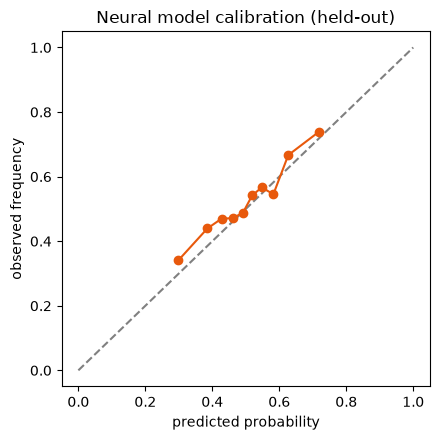

In [5]:
bins = np.quantile(p, np.linspace(0, 1, 11)); bins[0], bins[-1] = 0, 1
mid, obs = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    sel = (p >= lo) & (p < hi)
    if sel.sum(): mid.append(p[sel].mean()); obs.append(y[sel].mean())
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0,1],[0,1],"--",color="grey")
ax.plot(mid, obs, "o-", color="#e8590c")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Neural model calibration (held-out)")
plt.tight_layout(); plt.savefig(FIGURES/"neural_calibration.png", dpi=130); plt.show()

## 2. Comparison against the Bayesian models

| model | held-out log-loss | note |
|---|---|---|
| coin flip (baseline) | 0.6931 | |
| Bayesian additive (ADVI) | 0.6618 | different split, ADVI |
| **neural (Set Transformer)** | **see above** | own split, out-of-sample |

**Read with care.** The two numbers do not share an identical validation split, and the
Bayesian NUTS runs were not held-out validated at all (they used every match). A fully rigorous
three-way comparison requires all models refit on one shared training split and scored on the
same held-out rows. On the numbers as they stand the two approaches are close, and neither
clearly dominates, which is the expected outcome at this data scale.

In [6]:
summary = pd.DataFrame({
    "model": ["coin flip", "Bayesian additive (ADVI)", "neural (Set Transformer)"],
    "held-out log-loss": [0.6931, 0.6618, round(float(logloss), 4)],
})
display(summary)

,model,held-out log-loss
0,coin flip,0.6931
1,Bayesian additive (ADVI),0.6618
2,neural (Set Transformer),0.6692


## 3. Team ranking with MC-dropout
Each team is scored many times with dropout active; the spread is the uncertainty. Team scores
exclude any pilot component (the network has none), so they answer "how strong is this team".

In [7]:
def team_tensor(team):
    enc = encode_team(team, vocab)
    return {f: torch.tensor([enc[f]], dtype=torch.long, device=device) for f in FIELDS}

def mc_scores(team, n_mc=50):
    model.train()                        # dropout on
    with torch.no_grad():
        s = np.array([model.score(team_tensor(team)).item() for _ in range(n_mc)])
    model.eval()
    return s

def team_key(team):
    return tuple(sorted((m["species"], m.get("item"), m.get("ability"), m.get("nature"),
                         tuple(sorted(m.get("moves", [])))) for m in team))

rows = [json.loads(l) for l in open(DATA/"teams.jsonl", encoding="utf-8")]
uniq = {}
for r in rows:
    d = uniq.setdefault(team_key(r["team"]), {"team": r["team"], "n": 0}); d["n"] += 1
MIN_OCC, N_MC = 5, 50
cand = [v for v in uniq.values() if v["n"] >= MIN_OCC]
print(f"scoring {len(cand)} teams seen >= {MIN_OCC} times...")

recs = []
for v in cand:
    s = mc_scores(v["team"], N_MC)
    recs.append({"team": " / ".join(m["species"] for m in v["team"]), "n": v["n"],
                 "mean": float(s.mean()), "q5": float(np.percentile(s,5)),
                 "q95": float(np.percentile(s,95)), "_team": v["team"]})
rank = pd.DataFrame(recs).sort_values("mean", ascending=False).reset_index(drop=True)
display(rank.head(20)[["team","n","mean","q5","q95"]].round(3))
rank.drop(columns="_team").to_csv(RESULTS/"ranking_teams_neural.csv", index=False)

scoring 95 teams seen >= 5 times...


,team,n,mean,q5,q95
0,Incineroar / Gardevoir / Talonflame / Tsareena...,5,1.071,0.933,1.189
1,Swampert / Pelipper / Archaludon / Venusaur / ...,7,0.974,0.825,1.084
2,Blastoise / Delphox / Sneasler / Incineroar / ...,5,0.927,0.745,1.058
3,Sinistcha / Kingambit / Sneasler / Eternal Flo...,8,0.833,0.686,0.966
4,Delphox / Garchomp / Azumarill / Sinistcha / I...,5,0.826,0.643,1.043
5,Basculegion / Kingambit / Sneasler / Incineroa...,7,0.819,0.641,1.016
6,Delphox / Eternal Flower Floette / Sinistcha /...,7,0.798,0.639,0.950
7,Charizard / Eternal Flower Floette / Aegislash...,5,0.798,0.654,0.936
8,Swampert / Maushold / Archaludon / Pelipper / ...,6,0.796,0.619,0.949
9,Gholdengo / Incineroar / Basculegion / Garchom...,10,0.796,0.672,0.929


### Best team detail

In [8]:
best = rank.iloc[0]["_team"]
display(pd.DataFrame([{"species": m["species"], "ability": m.get("ability"),
                       "item": m.get("item"), "nature": m.get("nature"),
                       "moves": ", ".join(m.get("moves", []))} for m in best]))

,species,ability,item,nature,moves
0,Incineroar,Intimidate,Passho Berry,Careful,"Fake Out, Parting Shot, Throat Chop, Flare Blitz"
1,Gardevoir,Trace,Gardevoirite,Modest,"Protect, Vacuum Wave, Psyshock, Hyper Voice"
2,Talonflame,Gale Wings,Life Orb,Jolly,"Protect, Tailwind, Flare Blitz, Brave Bird"
3,Tsareena,Queenly Majesty,Wide Lens,Adamant,"Protect, Triple Axel, Low Kick, Power Whip"
4,Maushold,Friend Guard,Focus Sash,Timid,"Protect, Taunt, Follow Me, Super Fang"
5,Basculegion,Adaptability,Mystic Water,Adamant,"Protect, Aqua Jet, Wave Crash, Last Respects"


### Forest plot, top 15

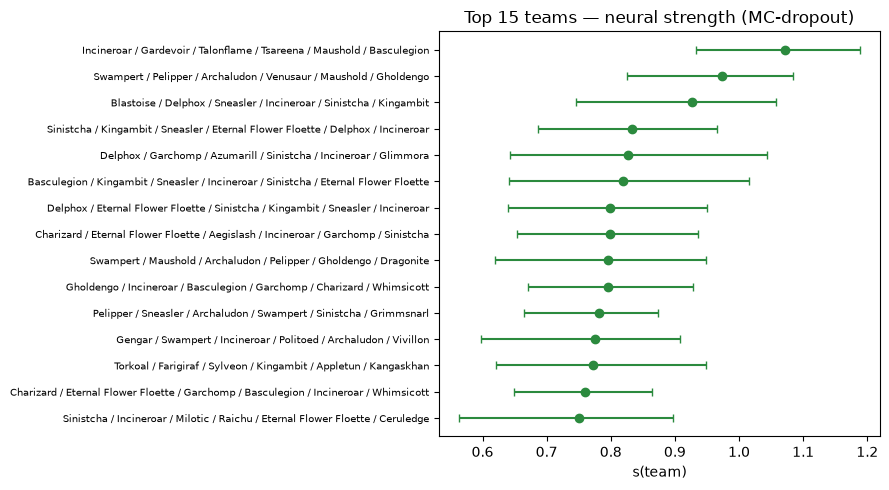

In [9]:
top = rank.head(15)[::-1]
yy = np.arange(len(top))
fig, ax = plt.subplots(figsize=(9,5))
ax.errorbar(top["mean"], yy, xerr=[top["mean"]-top["q5"], top["q95"]-top["mean"]],
            fmt="o", color="#2b8a3e", capsize=3)
ax.set_yticks(yy); ax.set_yticklabels(top["team"], fontsize=7)
ax.set_title("Top 15 teams — neural strength (MC-dropout)")
ax.set_xlabel("s(team)")
plt.tight_layout(); plt.savefig(FIGURES/"ranking_teams_neural.png", dpi=130); plt.show()

## 4. Head-to-head
Posterior (over dropout) probability that the top team beats the runner-up.

In [10]:
def head_to_head(tA, tB, n_mc=100):
    model.train()
    with torch.no_grad():
        p = np.array([torch.sigmoid(model.score(team_tensor(tA)) - model.score(team_tensor(tB))).item()
                      for _ in range(n_mc)])
    model.eval()
    return p

pAB = head_to_head(rank.iloc[0]["_team"], rank.iloc[1]["_team"])
print("A:", rank.iloc[0]["team"])
print("B:", rank.iloc[1]["team"])
print(f"P(A beats B) = {pAB.mean():.3f}  [{np.percentile(pAB,5):.3f}, {np.percentile(pAB,95):.3f}]")

A: Incineroar / Gardevoir / Talonflame / Tsareena / Maushold / Basculegion
B: Swampert / Pelipper / Archaludon / Venusaur / Maushold / Gholdengo
P(A beats B) = 0.520  [0.474, 0.567]


## How to read this

- The network's outputs are **team strengths and win probabilities**, not per-feature effects.
  For a per-Pokémon importance you would need ablation or attention-weight analysis; the
  Bayesian model remains the interpretable one.
- **MC-dropout intervals** approximate predictive uncertainty. They are not full Bayesian
  credible intervals, but serve the same role: a wide interval means low confidence.
- The **held-out log-loss** is the number that matters for comparison. As it stands the neural
  and Bayesian models are close; a clean verdict needs a shared split, which is the remaining
  step on the roadmap.